<a href="https://colab.research.google.com/github/eimoehtet/shopping-preferences-prediction/blob/main/shopping%20behavior%20prediction%20model%20using%20GaussianNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prediction model for shopping preferences using Gaussian Naive Bayes Classifier

### Importing the essential libraries for model training

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler, label_binarize
from imblearn.over_sampling import SMOTE
from collections import Counter
import gradio as gr


print('All libraries imported!')

All libraries imported!


### 1. Exploratory Data Analysis (EDA)

#### 1.1 Load the Dataset

In [2]:
# Load the dataset from the CSV file
df = pd.read_csv('/content/online vs store shopping dataset.csv')
print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


#### 1.2 Dataset Information

In [3]:
# Display concise summary of the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

#### 1.3 Missing Values

In [4]:
# Check for missing values in each column
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64


#### 1.4 Descriptive Statistics

In [5]:
# Display descriptive statistics for numerical columns
display(df.describe())

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### 1.5 Distribution of Target Variable: `shopping_preference`

/tmp/ipykernel_10987/351249525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='shopping_preference', data=df, palette=['#00187d'])
/tmp/ipykernel_10987/351249525.py:3: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='shopping_preference', data=df, palette=['#00187d'])


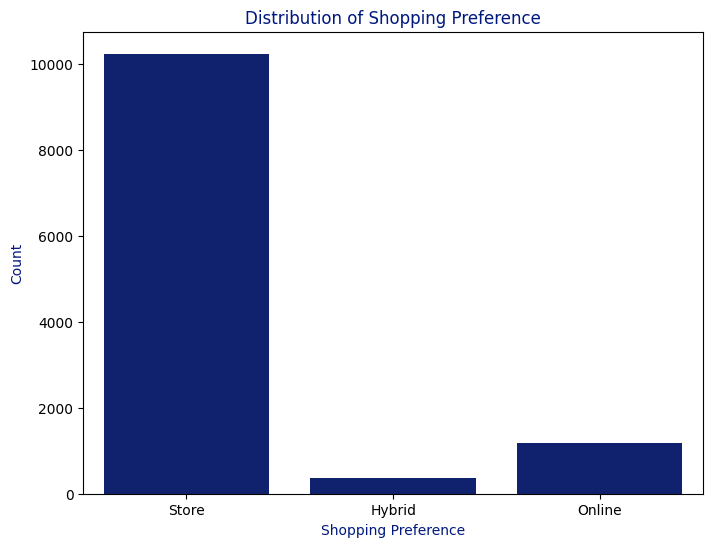

In [6]:
# Plot the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='shopping_preference', data=df, palette=['#00187d'])
plt.title('Distribution of Shopping Preference', color='#00187d')
plt.xlabel('Shopping Preference', color='#00187d')
plt.ylabel('Count', color='#00187d')
plt.show()

#### 1.6 Distribution of Numerical Features

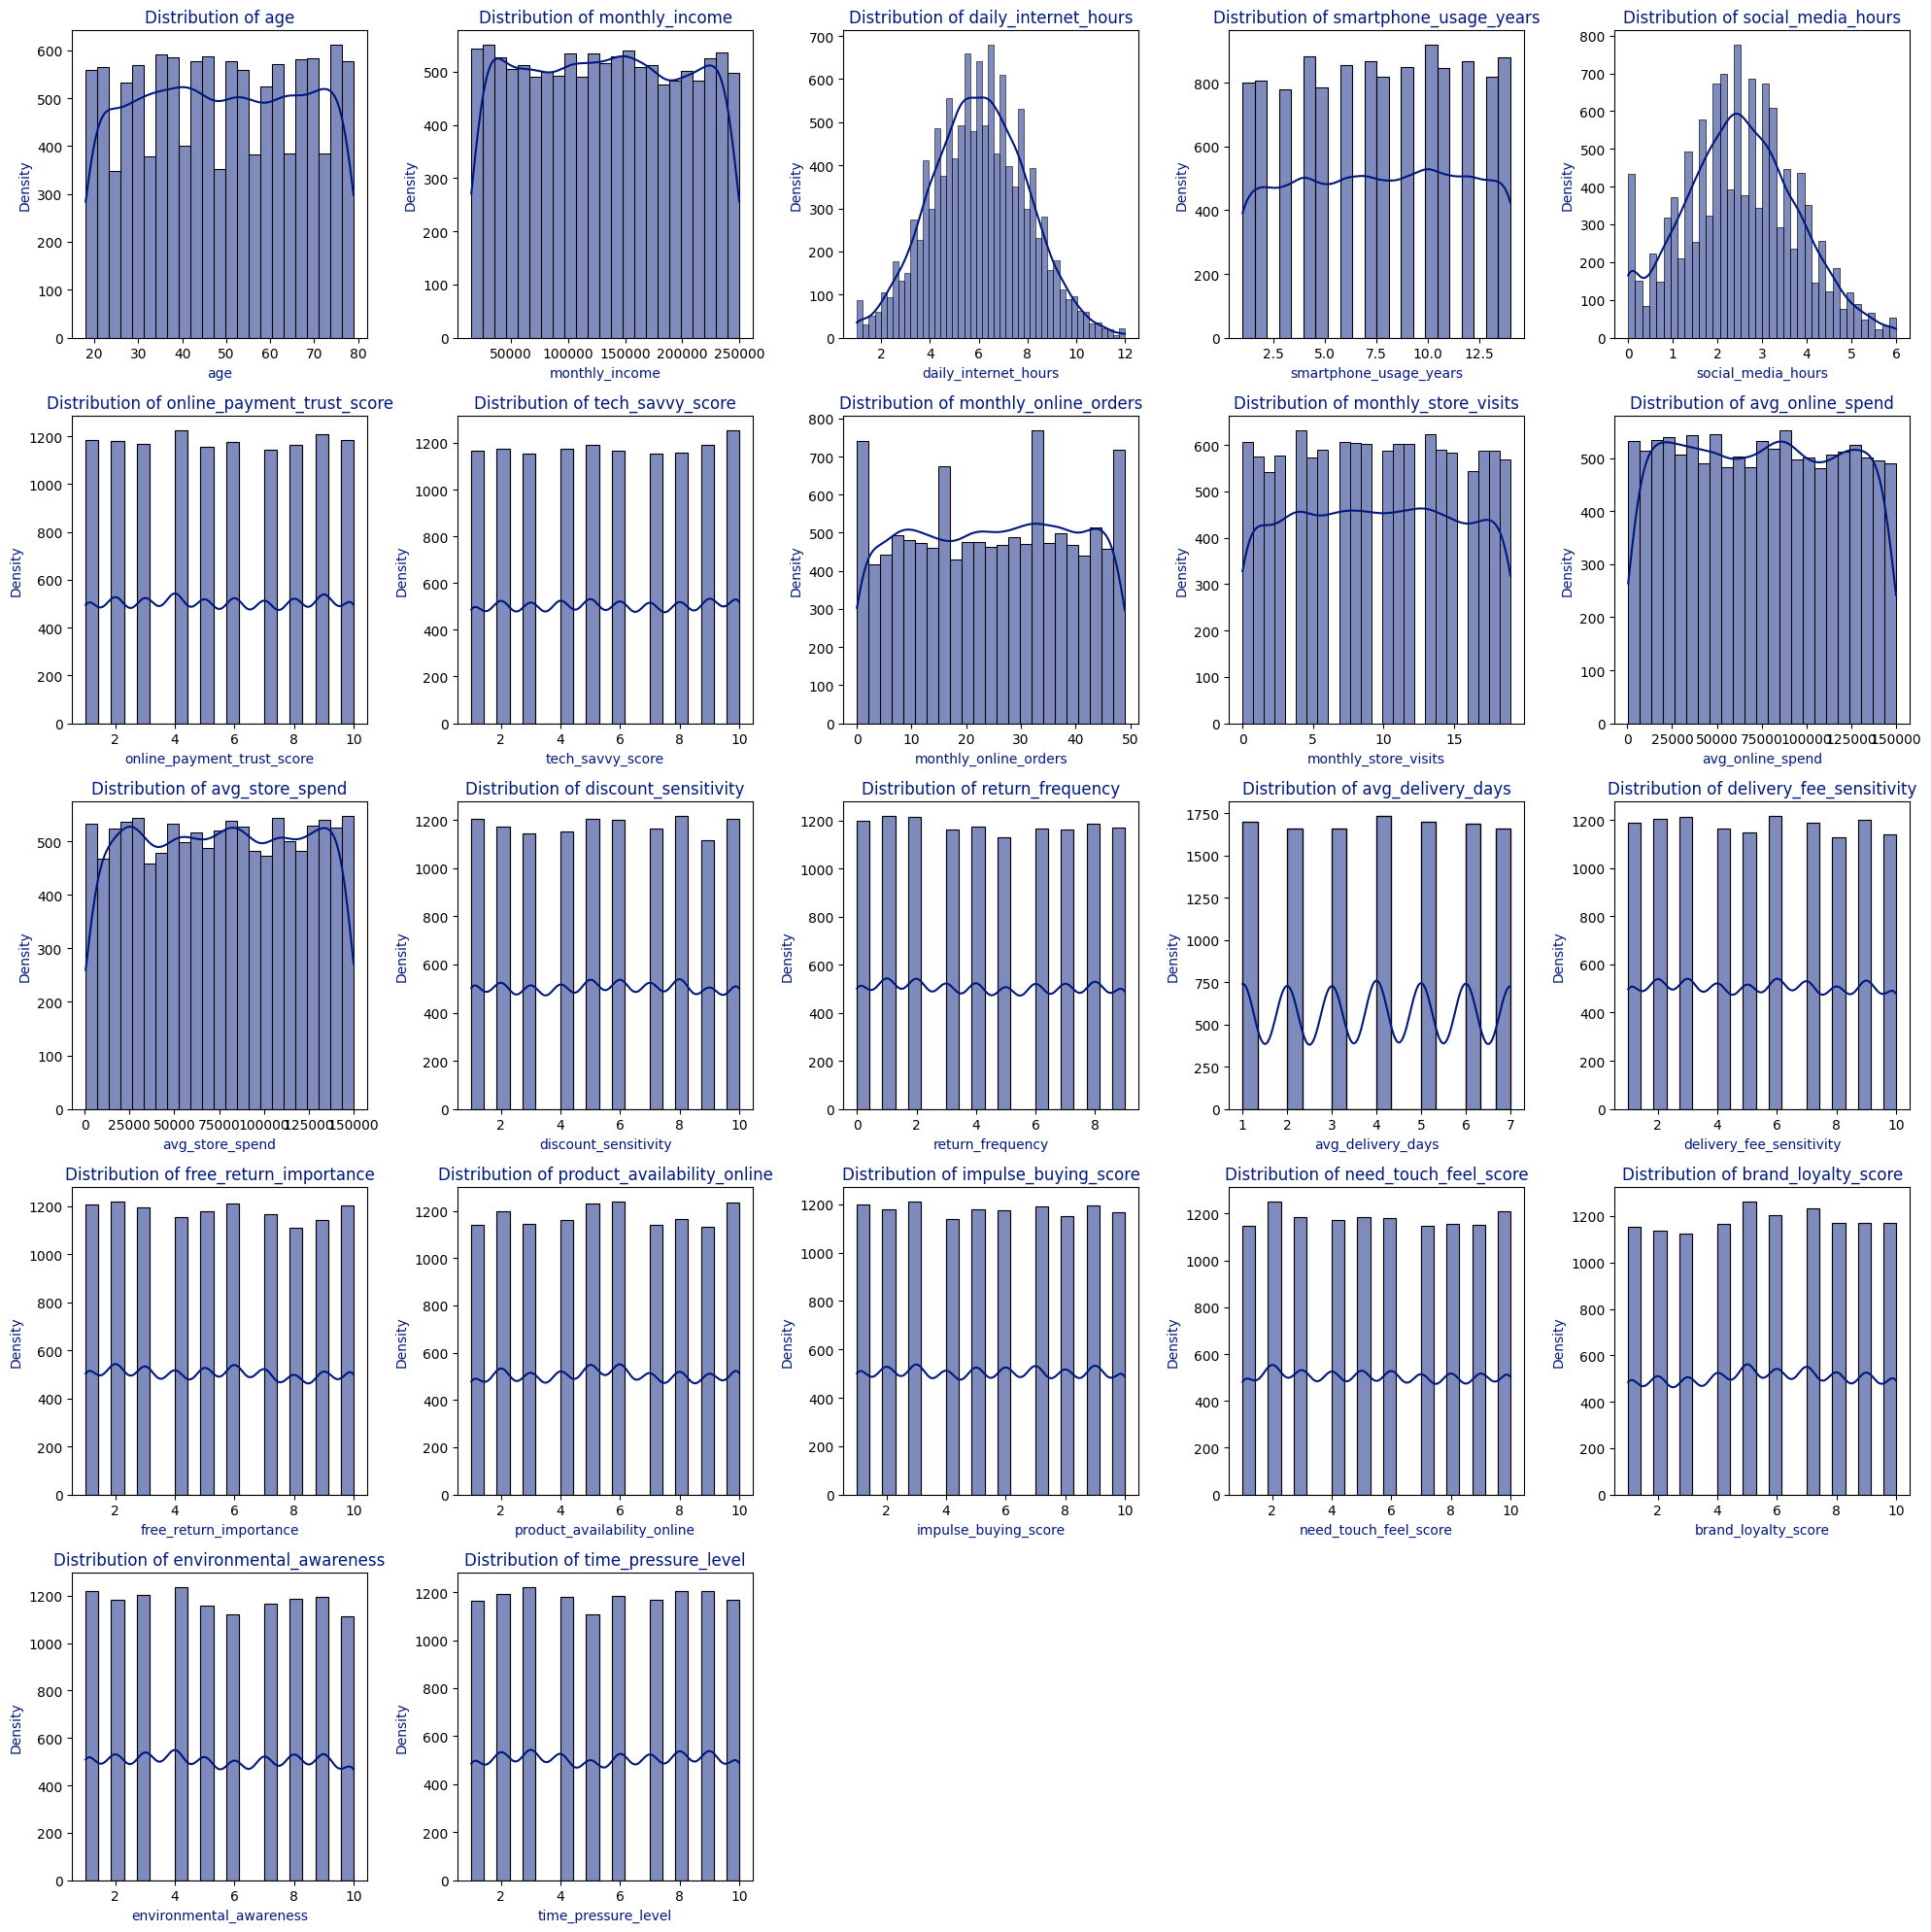

In [7]:
# Identify numerical columns for distribution plotting
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 20)) # Increased figure size for better visualization
for i, col in enumerate(numerical_features):
    plt.subplot(5, 5, i + 1) # Arrange plots in a 5x5 grid
    sns.histplot(df[col], kde=True, color="#00187d")
    plt.title(f'Distribution of {col}', color='#00187d')
    plt.xlabel(col, color='#00187d')
    plt.ylabel('Density', color='#00187d')
plt.tight_layout()
plt.show()

#### 1.7 Distribution of Categorical Features

/tmp/ipykernel_10987/2154905090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette=["#00187d"])
/tmp/ipykernel_10987/2154905090.py:7: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=col, data=df, palette=["#00187d"])
/tmp/ipykernel_10987/2154905090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette=["#00187d"])
/tmp/ipykernel_10987/2154905090.py:7: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=col, data=df, palette=["#00187d"])
/tmp/ipykernel_1

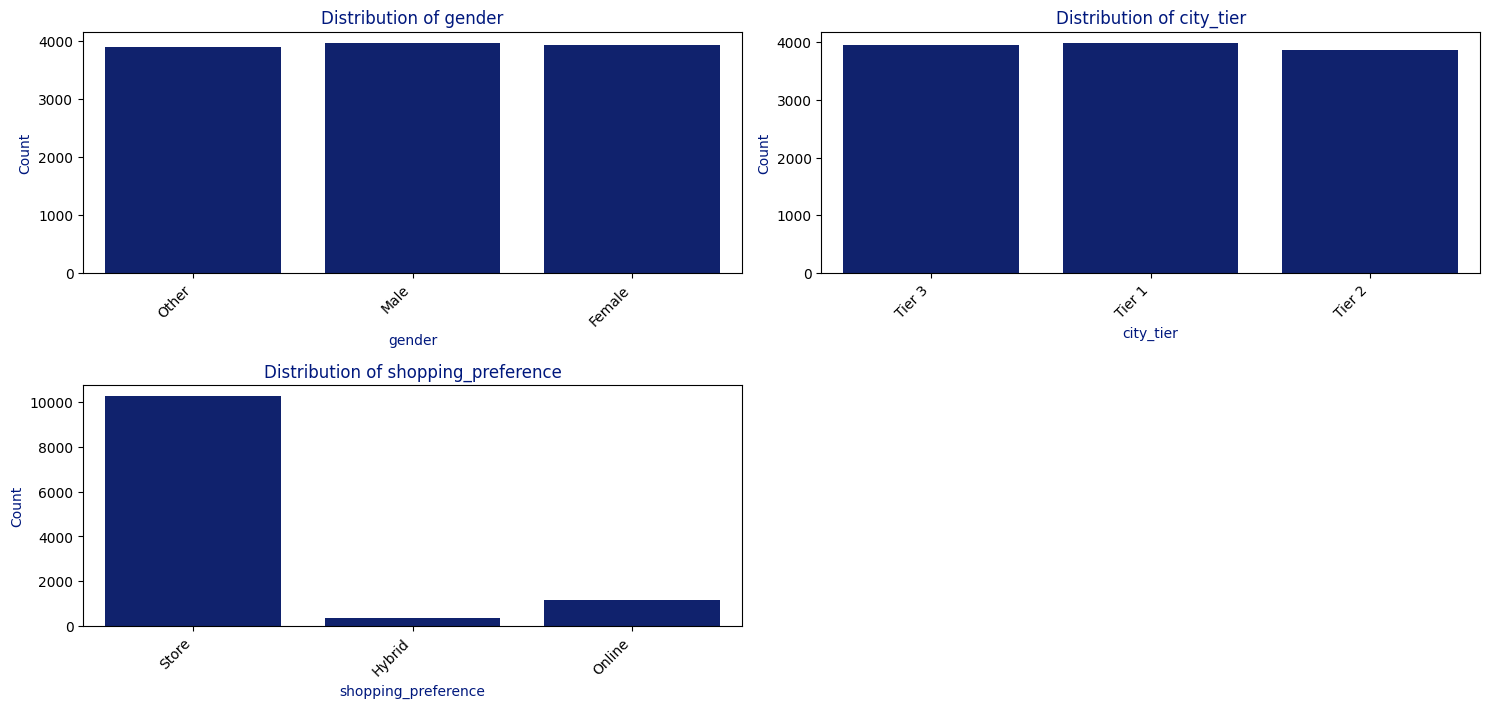

In [8]:
# Identify categorical columns for distribution plotting
categorical_features = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 3x2 grid
    sns.countplot(x=col, data=df, palette=["#00187d"])
    plt.title(f'Distribution of {col}', color='#00187d')
    plt.xlabel(col, color='#00187d')
    plt.ylabel('Count', color='#00187d')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

### 2. Preprocessing

#### 2.1 Encoding Categorical Features

In [9]:
# Perform one-hot encoding for categorical features
# drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['gender', 'city_tier', 'shopping_preference'], drop_first=True)

display(df_encoded.head())
print(f"Shape of encoded DataFrame: {df_encoded.shape}")

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3,shopping_preference_Online,shopping_preference_Store
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,3,6,5,2,False,True,False,True,False,True
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,6,8,1,7,True,False,False,True,False,False
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,1,3,3,3,False,False,False,True,False,True
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,8,2,6,6,False,False,False,False,False,True
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,9,7,1,6,True,False,False,True,False,True


Shape of encoded DataFrame: (11789, 28)


#### 2.2 Feature Scaling

In [10]:
# Identify numerical columns for scaling (excluding the one-hot encoded target columns)
numerical_cols_for_scaling = [col for col in df.select_dtypes(include=np.number).columns.tolist() if col not in ['shopping_preference']]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling to the numerical columns in df_encoded
df_scaled = df_encoded.copy()
df_scaled[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

display(df_scaled.head())
print("Numerical features scaled successfully.")

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3,shopping_preference_Online,shopping_preference_Store
0,0.622951,0.877107,0.500000,0.846154,0.116667,0.000000,0.555556,0.326531,0.842105,0.187512,...,0.222222,0.555556,0.444444,0.111111,False,True,False,True,False,True
1,0.836066,0.344806,0.654545,0.923077,0.450000,0.555556,0.888889,0.285714,0.052632,0.826457,...,0.555556,0.777778,0.000000,0.666667,True,False,False,True,False,False
2,0.459016,0.017235,0.490909,0.230769,0.350000,1.000000,0.777778,0.040816,0.000000,0.544687,...,0.000000,0.222222,0.222222,0.222222,False,False,False,True,False,True
3,0.229508,0.162415,0.490909,0.769231,0.116667,0.111111,1.000000,0.408163,0.157895,0.236685,...,0.777778,0.111111,0.555556,0.555556,False,False,False,False,False,True
4,0.688525,0.974581,0.454545,0.307692,0.116667,0.111111,0.444444,0.367347,0.842105,0.879410,...,0.888889,0.666667,0.000000,0.555556,True,False,False,True,False,True


Numerical features scaled successfully.


### 3. Model Development: Gaussian Naive Bayes

#### 3.1 Prepare Features (X) and Target (y)

In [11]:
# Define features (X) by dropping the one-hot encoded target columns
X = df_scaled.drop(columns=['shopping_preference_Online', 'shopping_preference_Store'])

# Reconstruct the target variable (y) from the one-hot encoded columns
# Assuming: 0 for Online, 1 for Store, 2 for Hybrid based on the original request context
# (Note: drop_first=True will remove one of the original classes, here 'Hybrid' if it was the last one.
# The mapping needs to align with how get_dummies creates columns and original class values.)
y = pd.Series(np.where(df_scaled['shopping_preference_Online'] == 1, 0,
                       np.where(df_scaled['shopping_preference_Store'] == 1, 1, 2)),
              index=df_scaled.index)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print("Target variable distribution:\n", y.value_counts())

Shape of X: (11789, 26)
Shape of y: (11789,)
Target variable distribution:
 1    10244
0     1176
2      369
Name: count, dtype: int64


#### 3.2 Split Data into Training and Testing Sets

In [12]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9431, 26)
X_test shape: (2358, 26)
y_train shape: (9431,)
y_test shape: (2358,)


#### 3.3 Addressing Class Imbalance with SMOTE and Training Initial Gaussian Naive Bayes

In [13]:
# Check the original class distribution in the training data
print("Original training set class distribution:", Counter(y_train))

# Initialize SMOTE (Synthetic Minority Over-sampling Technique)
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data to balance class distribution
X_res, y_res = sm.fit_resample(X_train, y_train)

# Check the new class distribution after SMOTE
print("Resampled training set class distribution:", Counter(y_res))

# Initialize the Gaussian Naive Bayes classifier (more suitable for continuous data)
gnb = GaussianNB()

# Train the model on the resampled data
gnb.fit(X_res, y_res)

print("Gaussian Naive Bayes model trained successfully on resampled data.")

Original training set class distribution: Counter({1: 8195, 0: 941, 2: 295})
Resampled training set class distribution: Counter({1: 8195, 0: 8195, 2: 8195})
Gaussian Naive Bayes model trained successfully on resampled data.


#### 3.4 Evaluate Initial Gaussian Naive Bayes Model

Gaussian Naive Bayes Accuracy (after SMOTE): 0.8694

Gaussian Naive Bayes Confusion Matrix (after SMOTE):
 [[  44   19   11]
 [  46  185    4]
 [ 225    3 1821]]


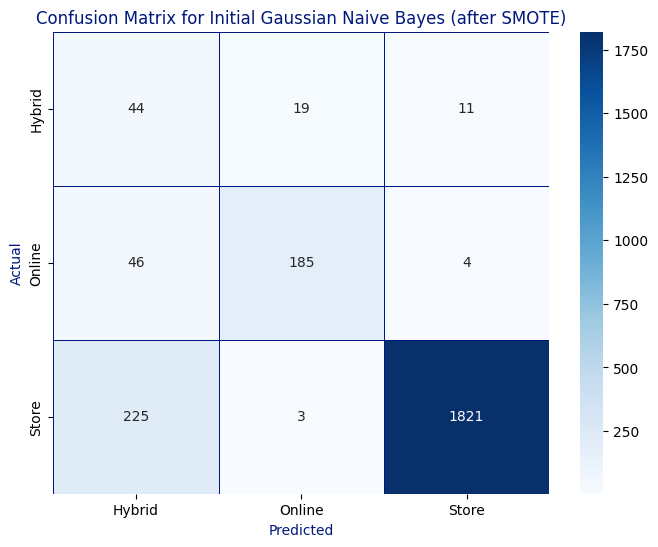

In [31]:
# Make predictions on the original (unresampled) test set
y_pred_gnb = gnb.predict(X_test)

# Evaluate the Gaussian Naive Bayes model
conf_matrix_gnb = confusion_matrix(y_test, y_pred_gnb, labels=[2, 0, 1])
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian Naive Bayes Accuracy (after SMOTE): {accuracy_gnb:.4f}")
print("\nGaussian Naive Bayes Confusion Matrix (after SMOTE):\n", conf_matrix_gnb)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hybrid', 'Online', 'Store'], yticklabels=['Hybrid', 'Online', 'Store'],
            linecolor='#00187d', linewidths=0.5)
plt.xlabel('Predicted', color='#00187d')
plt.ylabel('Actual', color='#00187d')
plt.title('Confusion Matrix for Initial Gaussian Naive Bayes (after SMOTE)', color='#00187d')
plt.show()

#### 3.5 Classification Report for Initial Gaussian Naive Bayes

In [32]:
# Generate and print the classification report for the GNB model
print("\nClassification Report for Initial Gaussian Naive Bayes (after SMOTE):\n")
# The labels 0, 1, 2 correspond to Online, Store, Hybrid respectively
print(classification_report(y_test, y_pred_gnb, target_names=['Hybrid', 'Online', 'Store'], labels=[2,0,1]))


Classification Report for Initial Gaussian Naive Bayes (after SMOTE):

              precision    recall  f1-score   support

      Hybrid       0.14      0.59      0.23        74
      Online       0.89      0.79      0.84       235
       Store       0.99      0.89      0.94      2049

    accuracy                           0.87      2358
   macro avg       0.68      0.76      0.67      2358
weighted avg       0.96      0.87      0.91      2358



#### 3.6 Hyperparameter Tuning for Gaussian Naive Bayes

In [ ]:
# Define the parameter grid for Gaussian Naive Bayes
# var_smoothing is the only significant hyperparameter, which adds to the variance of features
# It's a small positive value that regularizes the calculation of variances
param_grid_gnb = {
    'var_smoothing': np.logspace(0, -9, num=100) # Explore a wide range of smoothing values
}

# Initialize Gaussian Naive Bayes model for tuning
gnb_tuned_model = GaussianNB()

# Initialize GridSearchCV with 5-fold cross-validation and accuracy scoring
grid_search_gnb = GridSearchCV(estimator=gnb_tuned_model, param_grid=param_grid_gnb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_search_gnb.fit(X_res, y_res)

# Get the best model from GridSearchCV
best_gnb_model = grid_search_gnb.best_estimator_

# Print the best parameters and best cross-validation score
print("Best parameters found for Gaussian Naive Bayes: ", grid_search_gnb.best_params_)
print("Best cross-validation accuracy for Gaussian Naive Bayes: {:.4f}".format(grid_search_gnb.best_score_))

# Make predictions on the original (unresampled) test set using the best tuned model
y_pred_tuned_gnb = best_gnb_model.predict(X_test)
y_score_tuned_gnb = best_gnb_model.predict_proba(X_test)

print("Tuned Gaussian Naive Bayes model trained and predictions made successfully on the test set.")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


#### 3.7 Evaluate Tuned Gaussian Naive Bayes Model (Confusion Matrix)

Tuned Gaussian Naive Bayes Accuracy (after SMOTE and GridSearchCV): 0.8647

Tuned Gaussian Naive Bayes Confusion Matrix (after SMOTE and GridSearchCV):
 [[  51   14    9]
 [  41  193    1]
 [ 249    5 1795]]


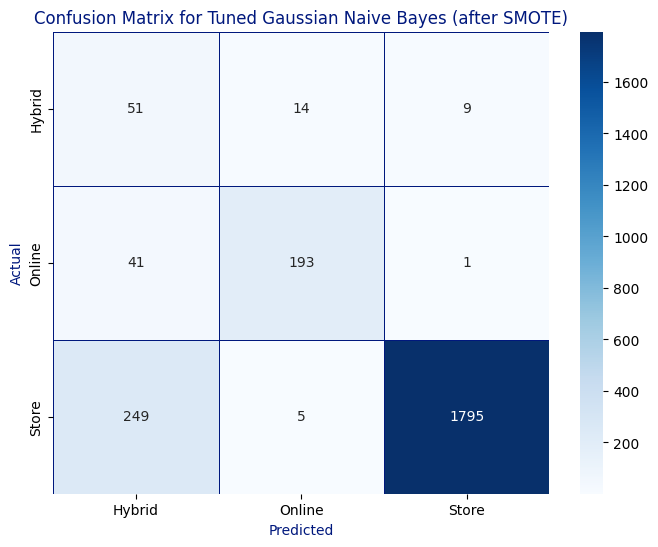

In [33]:
# Evaluate the tuned Gaussian Naive Bayes model
conf_matrix_tuned_gnb = confusion_matrix(y_test, y_pred_tuned_gnb, labels=[2, 0, 1])
accuracy_tuned_gnb = accuracy_score(y_test, y_pred_tuned_gnb)

print(f"Tuned Gaussian Naive Bayes Accuracy (after SMOTE and GridSearchCV): {accuracy_tuned_gnb:.4f}")
print("\nTuned Gaussian Naive Bayes Confusion Matrix (after SMOTE and GridSearchCV):\n", conf_matrix_tuned_gnb)

# Visualize Confusion Matrix for the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hybrid', 'Online', 'Store'], yticklabels=['Hybrid', 'Online', 'Store'],
            linecolor='#00187d', linewidths=0.5)
plt.xlabel('Predicted', color='#00187d')
plt.ylabel('Actual', color='#00187d')
plt.title('Confusion Matrix for Tuned Gaussian Naive Bayes (after SMOTE)', color='#00187d')
plt.show()

#### 3.8 Classification Report for Tuned Gaussian Naive Bayes

In [34]:
# Generate and print the classification report for the tuned GNB model
print("\nClassification Report for Tuned Gaussian Naive Bayes (after SMOTE and GridSearchCV):\n")
# The labels 0, 1, 2 correspond to Online, Store, Hybrid respectively
print(classification_report(y_test, y_pred_tuned_gnb, target_names=['Hybrid', 'Online', 'Store'], labels=[2,0,1]))


Classification Report for Tuned Gaussian Naive Bayes (after SMOTE and GridSearchCV):

              precision    recall  f1-score   support

      Hybrid       0.15      0.69      0.25        74
      Online       0.91      0.82      0.86       235
       Store       0.99      0.88      0.93      2049

    accuracy                           0.86      2358
   macro avg       0.68      0.80      0.68      2358
weighted avg       0.96      0.86      0.90      2358



#### 3.9 ROC Curve for Tuned Gaussian Naive Bayes

/tmp/ipykernel_10987/3305290775.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (area = 0.50)', color='#00187d')


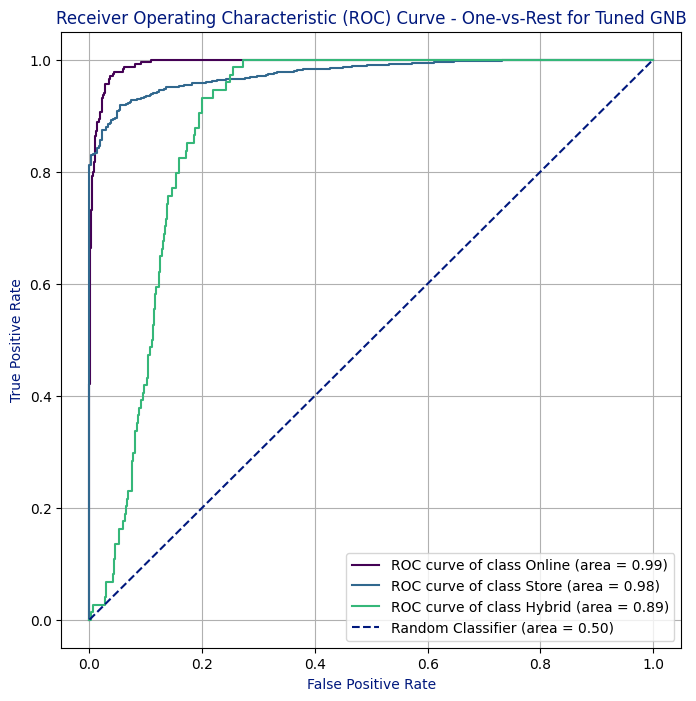

Micro-average ROC AUC: 0.98
Macro-average ROC AUC: 0.95


In [39]:
# One-hot encode y_test for multi-class ROC curve generation
n_classes = len(best_gnb_model.classes_)
y_test_binarized = label_binarize(y_test, classes=best_gnb_model.classes_)

# Initialize plot for ROC curves
plt.figure(figsize=(8, 8))

# Class labels mapping for better readability on the plot
class_labels_map = {0: 'Online', 1: 'Store', 2: 'Hybrid'}

# Store False Positive Rate (FPR), True Positive Rate (TPR), and Area Under Curve (AUC) for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Plot ROC curve for each class (One-vs-Rest)
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score_tuned_gnb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {class_labels_map[best_gnb_model.classes_[i]]} (area = {roc_auc[i]:.2f})', color=plt.cm.viridis(i/n_classes))

# Plot the random classifier line (baseline)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (area = 0.50)', color='#00187d')

plt.xlabel('False Positive Rate', color='#00187d')
plt.ylabel('True Positive Rate', color='#00187d')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest for Tuned GNB', color='#00187d')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calculate and print micro-average ROC AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_score_tuned_gnb.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
print(f"Micro-average ROC AUC: {roc_auc['micro']:.2f}")

# Calculate and print macro-average ROC AUC
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
print(f"Macro-average ROC AUC: {roc_auc['macro']:.2f}")

#### 3.10 Error Distribution Analysis for Tuned Gaussian Naive Bayes

<Figure size 1800x700 with 0 Axes>

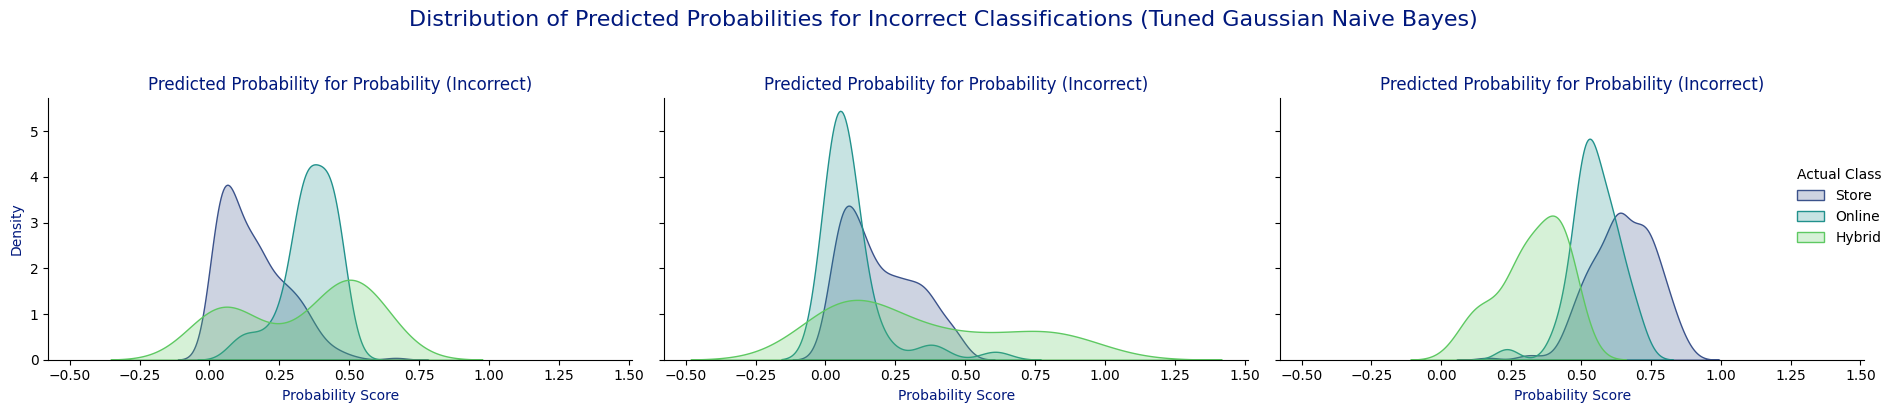

In [40]:
# Create a DataFrame for detailed analysis of predicted probabilities
# The probabilities (y_score_tuned_gnb) correspond to the order of classes in best_gnb_model.classes_
# Assuming 0: Online, 1: Store, 2: Hybrid
class_names_for_prob_df = [class_labels_map[c] for c in best_gnb_model.classes_]
prob_df = pd.DataFrame(y_score_tuned_gnb, columns=[f'Prob_{name}' for name in class_names_for_prob_df], index=y_test.index)

# Map numerical target labels back to original names for clarity
prob_df['Actual_Class'] = y_test.map(class_labels_map)
prob_df['Predicted_Class'] = pd.Series(y_pred_tuned_gnb, index=y_test.index).map(class_labels_map)
prob_df['Correct_Prediction'] = prob_df['Actual_Class'] == prob_df['Predicted_Class']

# Melt the DataFrame for easier plotting of probability distributions by actual and predicted classes
prob_melted = prob_df.melt(id_vars=['Actual_Class', 'Predicted_Class', 'Correct_Prediction'],
                           var_name='Predicted_Probability_For_Class',
                           value_name='Probability_Score')

# Filter for incorrect predictions to specifically analyze errors
incorrect_predictions = prob_df[prob_df['Correct_Prediction'] == False]

if not incorrect_predictions.empty:
    plt.figure(figsize=(18, 7))

    # Melt the DataFrame of incorrect predictions for plotting
    incorrect_melted = incorrect_predictions.melt(id_vars=['Actual_Class', 'Predicted_Class', 'Correct_Prediction'],
                                                  var_name='Predicted_Probability_For_Class',
                                                  value_name='Probability_Score')

    # Plot distributions of predicted probabilities for incorrect classifications
    g = sns.FacetGrid(incorrect_melted, col='Predicted_Probability_For_Class', hue='Actual_Class', col_wrap=3, height=4, aspect=1.5, palette='viridis')
    g.map(sns.kdeplot, 'Probability_Score', fill=True, common_norm=False)
    g.add_legend(title="Actual Class")

    # Customize titles and labels
    for i, ax in enumerate(g.axes.flat):
        # Extract the predicted class from the column title (e.g., 'Prob_Online' -> 'Online')
        predicted_prob_name = ax.get_title().split('_')[1] # Get 'Online', 'Store', 'Hybrid'
        ax.set_title(f'Predicted Probability for {predicted_prob_name} (Incorrect)', color='#00187d')
        ax.set_xlabel('Probability Score', color='#00187d')
        ax.set_ylabel('Density', color='#00187d')

    plt.suptitle('Distribution of Predicted Probabilities for Incorrect Classifications (Tuned Gaussian Naive Bayes)', y=1.02, color='#00187d', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No incorrect predictions to analyze error distribution.")

In [22]:
# Define the numerical and categorical columns from the original dataframe
# These are used to guide the Gradio inputs and the preprocessing steps.
original_numerical_cols = [
    'age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years',
    'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score',
    'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
    'avg_store_spend', 'discount_sensitivity', 'return_frequency',
    'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance',
    'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score',
    'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level'
]
original_categorical_cols = ['gender', 'city_tier']

# Function to predict shopping preference based on user inputs
def predict_shopping_preference(
    age, monthly_income, daily_internet_hours, smartphone_usage_years,
    social_media_hours, online_payment_trust_score, tech_savvy_score,
    monthly_online_orders, monthly_store_visits, avg_online_spend,
    avg_store_spend, discount_sensitivity, return_frequency,
    avg_delivery_days, delivery_fee_sensitivity, free_return_importance,
    product_availability_online, impulse_buying_score, need_touch_feel_score,
    brand_loyalty_score, environmental_awareness, time_pressure_level,
    gender, city_tier
):
    # Create a dictionary for the input features
    input_data = {
        'age': age, 'monthly_income': monthly_income, 'daily_internet_hours': daily_internet_hours,
        'smartphone_usage_years': smartphone_usage_years, 'social_media_hours': social_media_hours,
        'online_payment_trust_score': online_payment_trust_score, 'tech_savvy_score': tech_savvy_score,
        'monthly_online_orders': monthly_online_orders, 'monthly_store_visits': monthly_store_visits,
        'avg_online_spend': avg_online_spend, 'avg_store_spend': avg_store_spend,
        'discount_sensitivity': discount_sensitivity, 'return_frequency': return_frequency,
        'avg_delivery_days': avg_delivery_days, 'delivery_fee_sensitivity': delivery_fee_sensitivity,
        'free_return_importance': free_return_importance,
        'product_availability_online': product_availability_online, 'impulse_buying_score': impulse_buying_score,
        'need_touch_feel_score': need_touch_feel_score, 'brand_loyalty_score': brand_loyalty_score,
        'environmental_awareness': environmental_awareness, 'time_pressure_level': time_pressure_level,
        'gender': gender, 'city_tier': city_tier
    }

    # Convert to DataFrame (single row)
    input_df = pd.DataFrame([input_data])

    # Apply one-hot encoding, ensuring consistency with training data columns
    input_df_encoded = pd.get_dummies(input_df, columns=original_categorical_cols, drop_first=True)

    # Reindex to ensure all feature columns from training (X) are present and in the correct order
    # Fill any missing dummy columns (e.g., if 'gender_Male' isn't created because input was 'Female') with 0
    input_final = input_df_encoded.reindex(columns=X.columns, fill_value=0)

    # Scale numerical features using the pre-fitted scaler
    input_final[original_numerical_cols] = scaler.transform(input_final[original_numerical_cols])

    # Make prediction using the tuned Gaussian Naive Bayes model
    prediction_numeric = best_gnb_model.predict(input_final)[0]

    # Map numerical prediction back to original class label
    prediction_label = class_labels_map[prediction_numeric]

    return prediction_label

# Create Gradio interface inputs
gradio_inputs = []

# Add sliders for numerical features
for col in original_numerical_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    # Set step to 1 for integer columns, and a finer step for float columns
    step_val = 1 if df[col].dtype == 'int64' else (max_val - min_val) / 100.0
    gradio_inputs.append(gr.Slider(
        minimum=min_val, maximum=max_val, value=mean_val, step=step_val,
        label=col.replace('_', ' ').title()
    ))

# Add radio buttons for categorical features
gradio_inputs.append(gr.Radio(choices=df['gender'].unique().tolist(), value=df['gender'].mode()[0], label="Gender"))
gradio_inputs.append(gr.Radio(choices=df['city_tier'].unique().tolist(), value=df['city_tier'].mode()[0], label="City Tier"))

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_shopping_preference,
    inputs=gradio_inputs,
    outputs=gr.Textbox(label="Predicted Shopping Preference"),
    title="Customer behaviors prediction, GaussianNB (Demo)",
    description="Adjust the customer features to see the predicted shopping preference (Online, Store, or Hybrid)."
)

# Launch the interface
iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c3b429ef825ec511d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c3b429ef825ec511d4.gradio.live
